In [ ]:
!pip install -q imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)        # (7043, 21)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Fix TotalCharges — convert to numeric, blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check nulls
print(df.isnull().sum())

# Drop the 11 rows with null TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID — not useful for modeling
df.drop('customerID', axis=1, inplace=True)

# Encode target: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.shape)   # (7032, 20)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
(7032, 20)


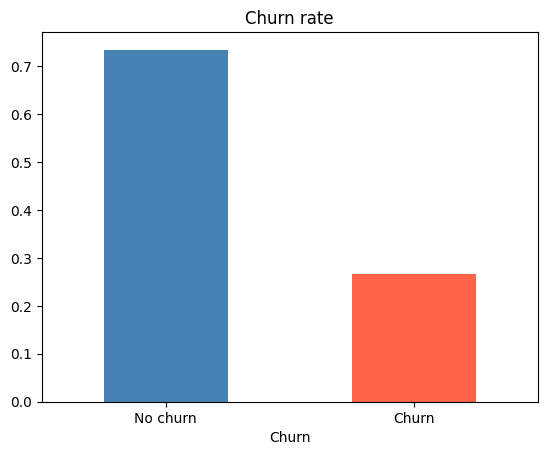

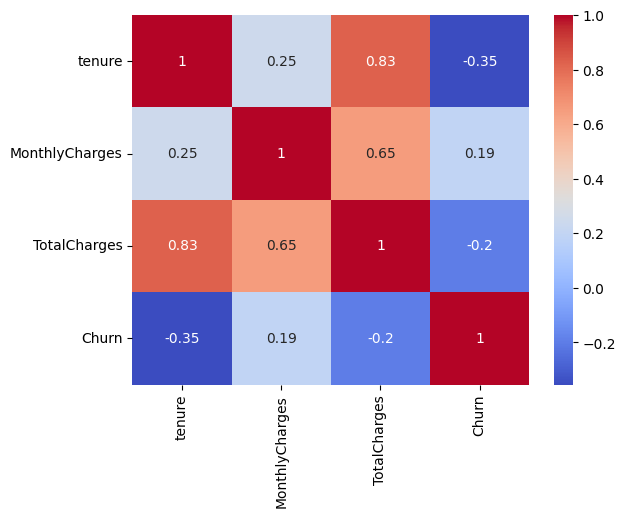

In [ ]:
# Churn distribution
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn rate')
plt.xticks([0,1], ['No churn', 'Churn'], rotation=0)
plt.show()
# ~26.5% churn — class imbalance; you'll fix this with SMOTE in Step 6

# Correlation of numeric features
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Separate binary and multi-class columns
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
multi_cols  = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
               'Contract','PaymentMethod']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)   # around (7032, 31)

(7032, 31)


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check class imbalance ratio — XGBoost handles this natively
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"scale_pos_weight should be: {scale}")  # roughly 2.7–2.8

scale_pos_weight should be: 2.76


In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

In [ ]:
##-----Model Train-----------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_lambda=2.0,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=30,   # stop if no improvement for 30 trees
    random_state=42,
    n_jobs=-1
)

eval_set = [(X_train, y_train), (X_test, y_test)]

xgb.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=50             # prints AUC every 50 trees
)

[0]	validation_0-auc:0.79891	validation_1-auc:0.78103
[50]	validation_0-auc:0.85669	validation_1-auc:0.83863
[100]	validation_0-auc:0.86538	validation_1-auc:0.84187
[125]	validation_0-auc:0.86835	validation_1-auc:0.84146


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

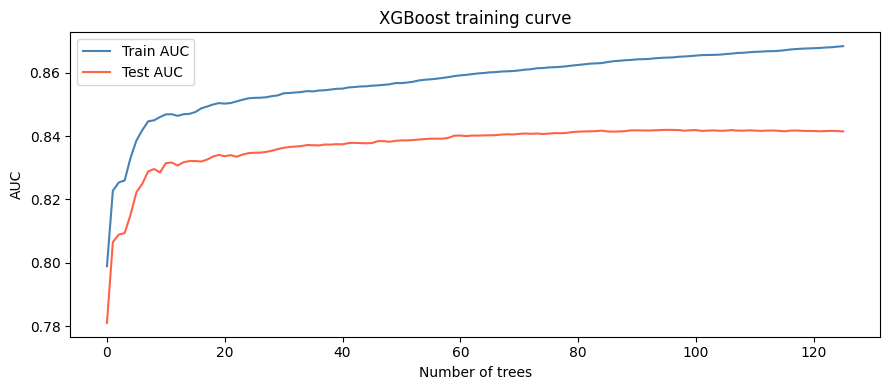

In [ ]:
results = xgb.evals_result()

plt.figure(figsize=(9, 4))
plt.plot(results['validation_0']['auc'], label='Train AUC', color='steelblue')
plt.plot(results['validation_1']['auc'], label='Test AUC',  color='tomato')
plt.xlabel('Number of trees')
plt.ylabel('AUC')
plt.title('XGBoost training curve')
plt.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.8419


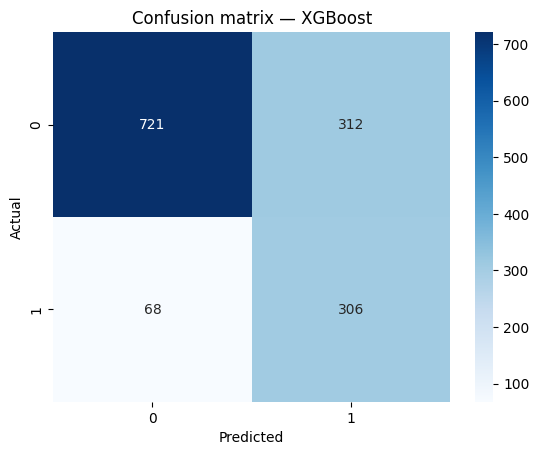

In [ ]:
y_pred  = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion matrix — XGBoost')
plt.show()

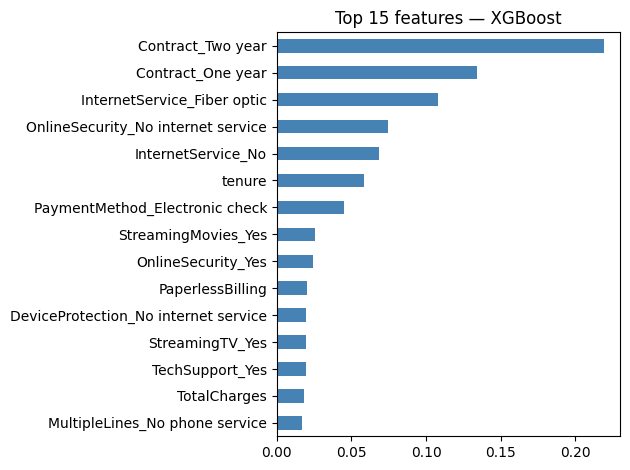

In [ ]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.nlargest(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 features — XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
import json
joblib.dump(xgb, 'churn_model.pkl')

with open('feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print("Saved: churn_model.pkl + feature_columns.json")

Saved: churn_model.pkl + feature_columns.json


In [ ]:
from google.colab import files

files.download('churn_model.pkl')
files.download('feature_columns.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Rename all columns to match PostgreSQL table exactly
df.columns = [
    'customer_ref', 'gender', 'senior_citizen', 'partner', 'dependents',
    'tenure', 'phone_service', 'multiple_lines', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
    'payment_method', 'monthly_charges', 'total_charges', 'churn'
]

df.to_csv('churn_clean.csv', index=False)
print('Saved:', len(df), 'rows')
print(df.columns.tolist())

Saved: 7032 rows
['customer_ref', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']
